# Report: Exploration of energy usage and devices over months

This report aims to answer the following questions:

- Which months have higher energy and gas usage?
- What patterns emerge from gas and electricity usage over time? (Cluster analysis)


In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from home_messages_db import *
import datetime
db = HomeMessagesDB("sqlite:///myhome.db")
db.create_db()

First lets insert the files into the database

In [3]:
db.insert_all()

And now fetch them and insert them into a pandas dataframe

In [4]:
p1e = db.return_whole_table("P1e")
p1g = db.return_whole_table("P1g")

Prepare data:

In [5]:
p1e["date"] = pd.to_datetime(p1e.loc[:,"epoch"]*10**9)
p1e["year"] = p1e["date"].dt.year
p1e["month"] = p1e["date"].dt.month
p1e["day_as_date"]=p1e["date"].dt.date
p1e["Usage"] = (p1e["Electricity_imported_T1"].diff() + p1e["Electricity_imported_T2"].diff()).fillna(0)

p1g["date"] = pd.to_datetime(p1e.loc[:,"epoch"]*10**9)
p1g["year"] = p1g["date"].dt.year
p1g["month"] = p1g["date"].dt.month
p1g["day_as_date"]=p1g["date"].dt.date
p1g["Usage"] = (p1g["Total_gas_used"].diff()).fillna(0)

p1e

,epoch,Electricity_imported_T1,Electricity_imported_T2,Electricity_exported_T1,Electricity_exported_T2,date,year,month,day_as_date,Usage
0,1647612900,6506.377,5313.255,0.0,0.0,2022-03-18 14:15:00,2022,3,2022-03-18,0.000
1,1647613800,6506.377,5313.516,0.0,0.0,2022-03-18 14:30:00,2022,3,2022-03-18,0.261
2,1647614700,6506.377,5314.241,0.0,0.0,2022-03-18 14:45:00,2022,3,2022-03-18,0.725
3,1647615600,6506.377,5314.800,0.0,0.0,2022-03-18 15:00:00,2022,3,2022-03-18,0.559
4,1647616500,6506.377,5314.933,0.0,0.0,2022-03-18 15:15:00,2022,3,2022-03-18,0.133
...,...,...,...,...,...,...,...,...,...,...
105996,1743151500,12906.475,10102.679,0.0,0.0,2025-03-28 08:45:00,2025,3,2025-03-28,0.047
105997,1743152400,12906.475,10102.860,0.0,0.0,2025-03-28 09:00:00,2025,3,2025-03-28,0.181
105998,1743153300,12906.475,10102.917,0.0,0.0,2025-03-28 09:15:00,2025,3,2025-03-28,0.057
105999,1743154200,12906.475,10102.997,0.0,0.0,2025-03-28 09:30:00,2025,3,2025-03-28,0.080


In [ ]:

p1e_new = p1e.groupby(by=["day_as_date","year","month"], as_index = False)["Usage"].aggregate(total_usage_electricity = "sum")
p1g_new = p1g.groupby(by=["day_as_date","year","month"], as_index = False)["Usage"].aggregate(total_usage_gas = "sum")

df = p1e_new.merge(p1g_new, how = "outer", on = ["day_as_date", "year", "month"])

## Electricity and gas usage over the months

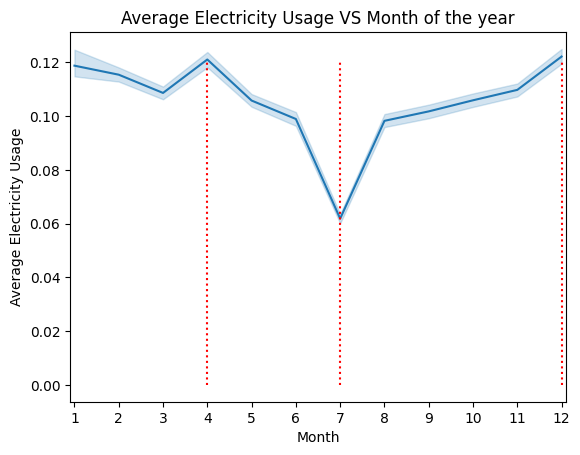

In [5]:
ax = sns.lineplot(p1e, x = "month", y = "Usage", estimator= "mean")
plt.xticks(np.arange(0,13, step = 1), rotation = 0, labels = range(0,13,1))
plt.xlim(0.9, 12.1)
plt.vlines(x = [4,12,7], ymin = 0, ymax= 0.12, linestyles= "dotted", color = "red")
ax.set(xlabel = "Month", ylabel = "Average Electricity Usage", title = "Average Electricity Usage VS Month of the year")
plt.show()

We see that energy consumption is higher in the months of April and December, and at it's lowest in the month of July. 

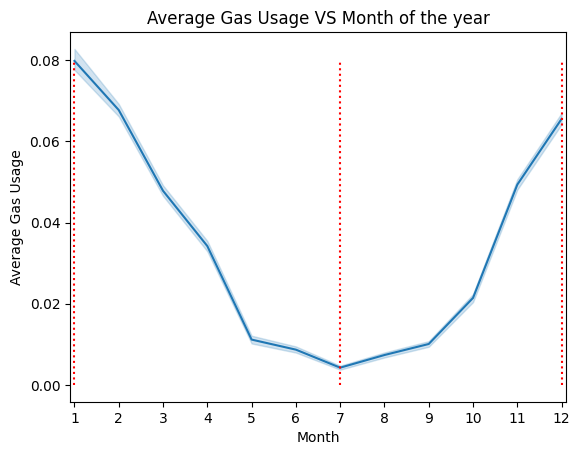

In [6]:
ax = sns.lineplot(p1g, x = "month", y = "Usage", estimator= "mean")
plt.xticks(np.arange(0,13, step = 1), rotation = 0, labels = range(0,13,1))
plt.xlim(0.9, 12.1)
plt.vlines(x = [1,12,7], ymin = 0, ymax= 0.08, linestyles= "dotted", color = "red")
ax.set(xlabel = "Month", ylabel = "Average Gas Usage", title = "Average Gas Usage VS Month of the year")
plt.show()

As expected we can see the consumption of gas is on average higher on the colder months, and lower in the summer months, since then no heating is used.

## Question 1b: Are there seasonal patterns in energy usage

After looking at the monthly patterns of energy consumption, one might also be interested in whether there are any seasonal patterns.

First we need to group the data based on the seasons of the year:

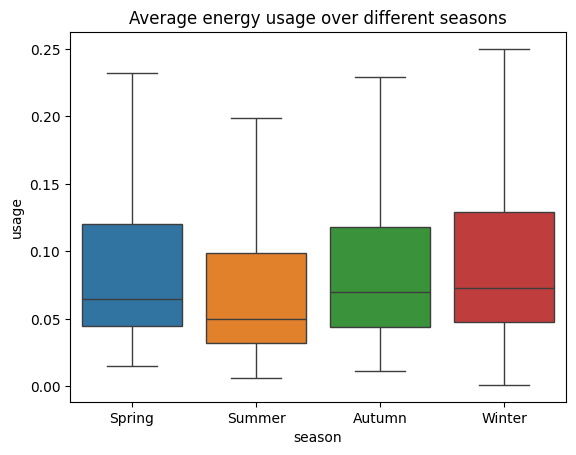

In [11]:
energy_usage = p1e.copy()
energy_usage["date"] = energy_usage["epoch"].apply(int).apply(timestamp_into_gmt2).dt.date
energy_usage["usage"] = energy_usage.loc[:,"Electricity_imported_T1"].diff() + energy_usage.loc[:,"Electricity_imported_T2"].diff()

month_temp = energy_usage["date"].apply(lambda x: x.replace(year = 2000))
spring_start = datetime.date(2000, 3, 1)
summer_start = datetime.date(2000, 6, 1)
autumn_start = datetime.date(2000, 9, 30)
winter_start = datetime.date(2000, 12, 1)
next_spring = datetime.date(2000, 2, 29)


conditions = [
    (month_temp >= spring_start) & (month_temp < summer_start),
    (month_temp >= summer_start) & (month_temp < autumn_start),
    (month_temp >= autumn_start) & (month_temp < winter_start),
    (month_temp >= winter_start) | (month_temp < spring_start)
]

choices = ["Spring", "Summer", "Autumn", "Winter"]

energy_usage['season'] = np.select(conditions, choices, default="Unknown")

ax = sns.boxplot(data = energy_usage, x= "season", y = "usage", showfliers = False,
            hue= "season")
ax.set_title("Average energy usage over different seasons")
plt.show()

We can see that energy usage is quite similar between Spring and Autumn, while being lower on average during the summer and showing the highest values during the winter. We would assume that this is because on average, more time is spent inside during colder seasons, meaning more time is spent using electronic devices that naturally consume energy. Furthermore, during winter, extra heating in the form of electrical heaters might be necessary to run from time to time, further driving up average usage.

After observing the average energy usage, let's take a look at the average gas usage over the four seasons:

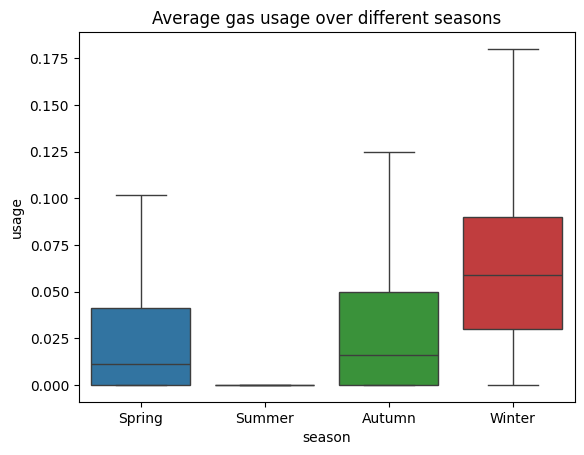

In [12]:
gas_usage = p1g.copy()
gas_usage["date"] = gas_usage["epoch"].apply(int).apply(timestamp_into_gmt2).dt.date
gas_usage["usage"] = gas_usage.loc[:,"Total_gas_used"].diff()


month_temp =gas_usage["date"].apply(lambda x: x.replace(year = 2000))
spring_start = datetime.date(2000, 3, 1)
summer_start = datetime.date(2000, 6, 1)
autumn_start = datetime.date(2000, 9, 30)
winter_start = datetime.date(2000, 12, 1)
next_spring = datetime.date(2000, 2, 29)


conditions = [
    (month_temp >= spring_start) & (month_temp < summer_start),
    (month_temp >= summer_start) & (month_temp < autumn_start),
    (month_temp >= autumn_start) & (month_temp < winter_start),
    (month_temp >= winter_start) | (month_temp < spring_start)
]

choices = ["Spring", "Summer", "Autumn", "Winter"]


gas_usage['season'] = np.select(conditions, choices, default="Unknown")
gas_usage.head(5000)
ax = sns.boxplot(data = gas_usage, x= "season", y = "usage", showfliers = False,
            hue= "season")
ax.set_title("Average gas usage over different seasons")
plt.show()

We can observe that gas usage has a similar pattern to energy usage overall, but with distinct differences. Once again, it's evident that Spring and Autumn are quite similar, with autumn having slightly higher values than spring. This again is logical because one can assume that the biggest factor in determining gas usage is temperature, which should be quite similar between spring and autumn (with autumn potentially having some colder and rainier days which might prompt higher gas usage). 

During the summer instead we observe all values being close to zero or zero with almost no variability, which is understandable given that heating is usually not necessary during the summer, although it might point to the fact that no other appliances like the stove run on gas for this particular household. 

For Winter usage is the highest out of all the seasons, which is explained by the low temperatures which increase the need for heating. Interestingly we can also observe that the range of values is the highest for Winter and even more surprisingly that for some days no gas was used. A potential reason for this will be explored in the next section.

## Clustering date by gas and energy usage : K-means clustering

In order to identify if there are monthly patterns in gas and electricity usage, we will perform k-means clustering on the data.

### Scree plot

We start by making a scree plot to identify the optimal number of k clusters.

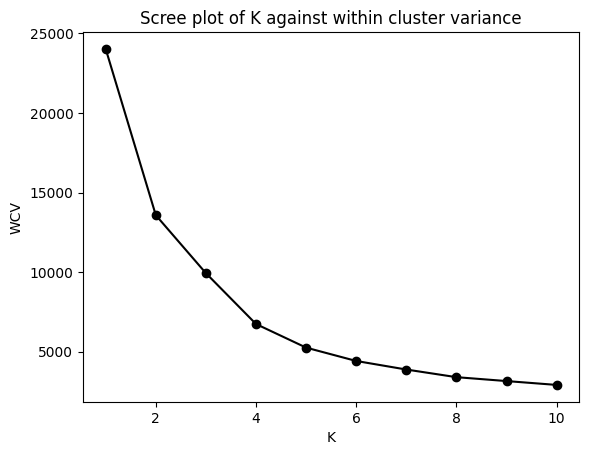

In [14]:
from sklearn.cluster import KMeans
ss = []

for i in range(1,11):
    k = KMeans(n_clusters = i, random_state=42).fit(df[["total_usage_gas","total_usage_electricity"]])
    ss.append(k.inertia_)

plt.plot([i for i in range(1,11)], ss, 'o-', color = "black")
plt.title("Scree plot of K against within cluster variance")
plt.xlabel("K")
plt.ylabel("WCV")
plt.show()


To decide on the number of clusters, we can use the scree plot where we plot the number of clusters (k) against the Within Cluster variance (WCV). We aim to minimize the WCV while choosing the smallest k, for which we can look at the lowest k that generates a significant drop in WCV, this is known as the "elbow" (because of the line's shape). From the scree plot we can see the "elbow" is located around k = 4, so we'll choose to have 4 clusters. 

In [15]:
model = KMeans(n_clusters = 4,random_state = 42).fit(df[["total_usage_gas","total_usage_electricity"]])
label = model.predict(df[["total_usage_gas","total_usage_electricity"]])
p1e_new["label"] = label

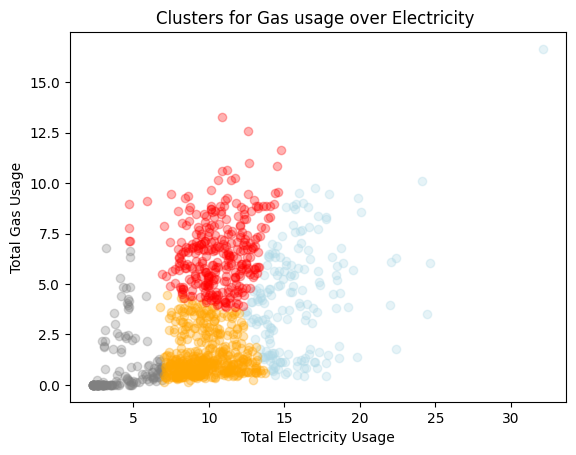

In [16]:

plt.scatter(df.loc[label == 0, "total_usage_electricity"], df.loc[label == 0, "total_usage_gas"], color = "lightblue", alpha = 0.3)
plt.scatter(df.loc[label == 1, "total_usage_electricity"], df.loc[label == 1, "total_usage_gas"], color = "grey", alpha = 0.3)
plt.scatter(df.loc[label == 2, "total_usage_electricity"], df.loc[label == 2, "total_usage_gas"], color = "orange", alpha = 0.3)
plt.scatter(df.loc[label == 3, "total_usage_electricity"], df.loc[label == 3, "total_usage_gas"], color = "red", alpha = 0.3)
plt.title("Clusters for Gas usage over Electricity ")
plt.xlabel("Total Electricity Usage")
plt.ylabel("Total Gas Usage")
plt.show()

After performing k-means clustering using k = 4, we obtain the following groups:

- Gray: days when both electricity is low (with variable gas values), possibly indicating these are days where the family was not at home.
- Blue: days when electricity usage was high (with variable gas values), which could be days where the family is at home and using many of the appliances.
- Yellow: days with average electricity use paired with low gas use, indicating days that could belong to warm seasons.
- Red: days with average electricity use with high gas use, indicating days belonging to cold seasons.

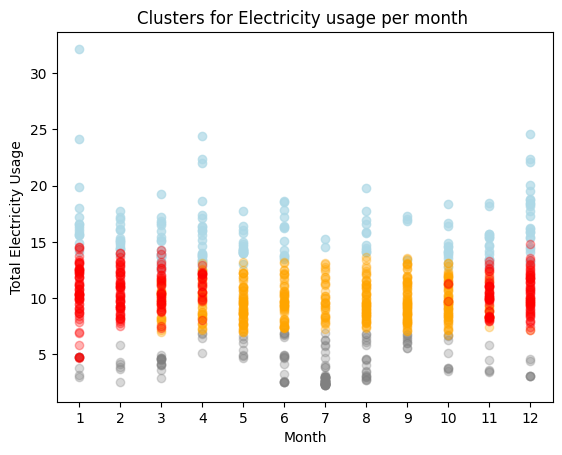

In [26]:
plt.scatter(df.loc[label == 0, "month"], df.loc[label == 0, "total_usage_electricity"], color = "lightblue", alpha = 0.7)
plt.scatter(df.loc[label == 1, "month"], df.loc[label == 1, "total_usage_electricity"], color = "grey", alpha = 0.3)
plt.scatter(df.loc[label == 2, "month"], df.loc[label == 2, "total_usage_electricity"], color = "orange", alpha = 0.3)
plt.scatter(df.loc[label == 3, "month"], df.loc[label == 3, "total_usage_electricity"], color = "red", alpha = 0.3)
plt.title("Clusters for Electricity usage per month ")
plt.xticks(np.arange(1,13, step = 1), rotation = 0, labels = range(1,13,1))
plt.xlabel("Month")
plt.ylabel("Total Electricity Usage")
plt.show()


We can see here the yellow group (average electricity, low gas) is mainly comprised of the summer months, while the red group (average electricity, high gas) is located around the winter months; both clusters are reasonable in the context of the data because given temperatures are higher in the summer, heating isn't widely used, in contrast to the winter months when gas usage increases because of the need for heating. 

For the case of gray and blue groups these just mark the days of very low electricity consumption and very high electricity consumption, respectively.

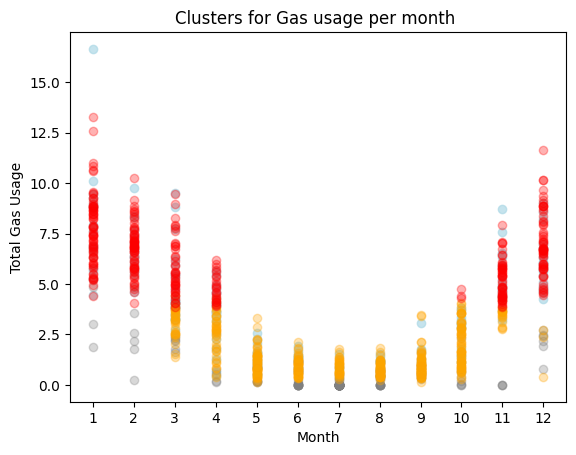

In [25]:
plt.scatter(df.loc[label == 0, "month"], df.loc[label == 0, "total_usage_gas"], color = "lightblue", alpha = 0.7)
plt.scatter(df.loc[label == 1, "month"], df.loc[label == 1, "total_usage_gas"], color = "grey", alpha = 0.3)
plt.scatter(df.loc[label == 2, "month"], df.loc[label == 2, "total_usage_gas"], color = "orange", alpha = 0.3)
plt.scatter(df.loc[label == 3, "month"], df.loc[label == 3, "total_usage_gas"], color = "red", alpha = 0.3)

plt.title("Clusters for Gas usage per month ")
plt.xticks(np.arange(1,13, step = 1), rotation = 0, labels = range(1,13,1))
plt.xlabel("Month")
plt.ylabel("Total Gas Usage")
plt.show()

Similarly as for electricity, in this case we can observe the yellow group (average electricity, low gas) is mainly comprised of the summer months, while the red group (average electricity, high gas) is located around the winter months. For the case of gray and blue groups these simply mark the days of very low electricity consumption and very high electricity consumption, respectively (no specific trends for gas usage).